# Plot UMAPs

This notebook generates UMAP plots for the organoid dataset.

**Inputs**
- Pooled UMAP embeddings from `1.EDA/results/umap/`, produced by `0.generate_umap.ipynb`.
- Per-patient embeddings from `1.EDA/results/umap/patient_specific/`, produced by `0.generate_umap.ipynb`. Each file consolidates all patients' independently-fit UMAP results for one projection/variant combo, with patient identity kept as a metadata column.
- `data/patient_IDs.txt` for the canonical patient list.
- `utils/r_plot_themes.r` for shared color palettes and plot themes.

**Outputs** (under `1.EDA/figures/umaps/`)
- Combined PDFs for the all-patient 3D, 2D max-projection, and 2D middle-slice plots.
- Combined, multi-page PDFs (one page per patient) for the per-patient plots, under `patient_specific/`.

The notebook will preview all plots, but only saves combined PDFs (no individual PNGs).

## Imports

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "circlize", "RColorBrewer")
for (package in list_of_packages) {
  suppressPackageStartupMessages(
    suppressWarnings(
      library(
        package,
        character.only = TRUE,
        quietly = TRUE,
        warn.conflicts = FALSE
      )
    )
  )
}

## Plotting helper

Shared functions used throughout: 

- `plot_umap()` builds/saves a single UMAP scatterplot (colored or faceted)
- `save_plots_pdf()` bundles a list of plots into one multi-page PDF.

In [2]:
plot_umap <- function(data, output_path = NULL, title,
                       color_by = NULL, palette = NULL, legend_title = NULL,
                       facet_by = NULL, facet_nrow = 2,
                       alpha = 0.5, point_size = 1, background_alpha = 0.15,
                       width = 10, height = 5, dpi = 300,
                       base_size = 8, fixed_coord = TRUE,
                       extra_theme = NULL, rasterize_dpi = NULL) {
  # Build, optionally save, and return a single UMAP scatterplot in a
  # consistent style.
  #
  # Two color modes:
  # - Unfaceted (facet_by is None): points colored by color_by using palette,
  #   with a legend.
  # - Faceted (facet_by is set): every panel shows the full point cloud dimmed
  #   grey as context, plus that panel's own group highlighted using color_by
  #   and palette (same variable/palette as facet_by, matching the
  #   corresponding non-faceted plot's colors). No legend, since the facet
  #   strip label already identifies the group.
  #
  # Parameters
  # ----------
  # data : data.frame
  #     Data frame containing UMAP1, UMAP2, and the columns referenced by
  #     color_by and (optionally) facet_by.
  # output_path : str or None, optional
  #     File path the plot is saved to via ggsave(). If None, the plot is
  #     built and returned but not saved (e.g. to collect pages for a
  #     combined multi-page PDF built by the caller).
  # title : str
  #     Plot title.
  # color_by : str
  #     Column name in `data` used to color points. In faceted mode this is
  #     normally the same column as facet_by.
  # palette : named vector
  #     Colors keyed by the values of `color_by`, passed to scale_color_manual().
  # legend_title : str or None, optional
  #     Legend title for the color scale (unfaceted mode only; faceted mode
  #     never shows a legend). If None, no title override is applied.
  # facet_by : str or None, optional
  #     Column name in `data` to facet by. If None, the plot is not faceted.
  # facet_nrow : int, optional
  #     Number of rows to use when faceting (ignored if facet_by is None).
  # alpha : float, optional
  #     Point transparency, in [0, 1]. In faceted mode, this applies to the
  #     highlighted points only.
  # point_size : float, optional
  #     Point size.
  # background_alpha : float, optional
  #     Transparency of the grey context points in faceted mode (ignored if
  #     facet_by is None).
  # width, height : float, optional
  #     Plot dimensions in inches, used both for the inline render size and
  #     the saved file.
  # dpi : int, optional
  #     Resolution (dots per inch) for the saved file (ignored if
  #     output_path is None).
  # base_size : int, optional
  #     Base font size passed to theme_manuscript().
  # fixed_coord : bool, optional
  #     If True, applies coord_fixed() so UMAP1/UMAP2 share a 1:1 scale. If a
  #     particular plot looks wrong with this on, set it False and adjust
  #     width/height instead.
  # extra_theme : ggplot2 theme or None, optional
  #     Theme object added on top of theme_manuscript(), or None to skip.
  # rasterize_dpi : int or None, optional
  #     If set, point layers are rasterized (via ggrastr) at this resolution
  #     instead of staying vector, while axes/text/labels stay vector. Keeps
  #     file size down for plots with many points, e.g. combined PDFs.
  #
  # Returns
  # -------
  # ggplot
  #     The plot object, returned visibly. Auto-prints when called at the
  #     top level of a cell; wrap in print() when called inside a loop,
  #     since R does not auto-print loop-body expressions.
  options(repr.plot.width = width, repr.plot.height = height)

  point_layer <- function(...) {
    layer <- geom_point(...)
    if (!is.null(rasterize_dpi)) {
      layer <- ggrastr::rasterise(layer, dpi = rasterize_dpi)
    }
    layer
  }

  # Compact legend styling: smaller key swatches and tighter spacing so
  # many-row legends (e.g. 12 patients, 22 treatments) fit within the plot
  # instead of getting cut off, especially in the combined PDFs.
  compact_legend_theme <- theme(
    legend.key.size = unit(0.3, "cm"),
    legend.spacing.y = unit(0.05, "cm"),
    legend.text = element_text(size = base_size * 0.8),
    legend.title = element_text(size = base_size * 0.9)
  )

  if (!is.null(facet_by)) {
    # Full point cloud, minus the facet column, so this layer repeats
    # unchanged in every panel instead of being split by facet.
    background_data <- data
    background_data[[facet_by]] <- NULL

    p <- ggplot(data, aes(x = UMAP1, y = UMAP2, color = .data[[color_by]])) +
      point_layer(data = background_data, color = "grey80", alpha = background_alpha, size = point_size) +
      point_layer(alpha = alpha, size = point_size) +
      scale_color_manual(values = palette) +
      guides(color = "none") +
      labs(title = title, x = "UMAP 1", y = "UMAP 2") +
      theme_manuscript(base_size = base_size) +
      facet_wrap(as.formula(paste0("~", facet_by)), nrow = facet_nrow)
  } else {
    guide_args <- list(override.aes = list(alpha = 1, size = 2), ncol = 1)
    if (!is.null(legend_title)) {
      guide_args$title <- legend_title
    }

    p <- ggplot(data, aes(x = UMAP1, y = UMAP2, color = .data[[color_by]])) +
      point_layer(alpha = alpha, size = point_size) +
      scale_color_manual(values = palette) +
      labs(title = title, x = "UMAP 1", y = "UMAP 2") +
      theme_manuscript(base_size = base_size) +
      compact_legend_theme +
      guides(color = do.call(guide_legend, guide_args))
  }

  if (fixed_coord) {
    p <- p + coord_fixed()
  }

  if (!is.null(extra_theme)) {
    p <- p + extra_theme
  }

  if (!is.null(output_path)) {
    ggsave(p, file = output_path, width = width, height = height, dpi = dpi)
  }
  p
}

In [3]:
save_plots_pdf <- function(plots, output_path, width = 10, height = 5) {
  # Save a list of ggplot objects as a single multi-page PDF, one page per
  # plot, in list order.
  #
  # Parameters
  # ----------
  # plots : list of ggplot
  #     Plots to save, one per page.
  # output_path : str
  #     File path for the combined PDF.
  # width, height : float, optional
  #     Page dimensions in inches.
  pdf(output_path, width = width, height = height)
  # Guarantees the device closes even if print(p) errors partway through,
  # so a failure stays local to this PDF instead of leaving the device open
  # for whatever gets plotted next.
  on.exit(dev.off(), add = TRUE)
  for (p in plots) {
    print(p)
  }
}

In [4]:
# Get the current working directory and find Git root
find_git_root <- function() {
  # Get current working directory
  cwd <- getwd()

  # Check if current directory has .git
  if (dir.exists(file.path(cwd, ".git"))) {
    return(cwd)
  }

  # If not, search parent directories
  current_path <- cwd
  while (dirname(current_path) != current_path) { # While not at root
    parent_path <- dirname(current_path)
    if (dir.exists(file.path(parent_path, ".git"))) {
      return(parent_path)
    }
    current_path <- parent_path
  }

  # If no Git root directory found, stop with error
  stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")

Git root directory: /Users/waygr/repos/wayscience/NF1_organoid_profile_analysis 


In [5]:
# Shared color palettes/themes (e.g. custom_treatment_palette, custom_MOA_palette,
# tab20_palette_for_patients, theme_manuscript) live in utils/r_plot_themes.r so
# that colors stay consistent across notebooks.
source(file.path(root_dir, "utils/r_plot_themes.r"))

In [6]:
figures_path <- file.path(root_dir, "1.EDA/figures/umaps")
if (!dir.exists(figures_path)) {
  dir.create(figures_path, recursive = TRUE)
}

figures_patient_specific_path <- file.path(figures_path, "patient_specific")
if (!dir.exists(figures_patient_specific_path)) {
  dir.create(figures_patient_specific_path, recursive = TRUE)
}

umap_results_dir <- file.path(root_dir, "1.EDA/results/umap")

## Load UMAP results

Reads the pooled all-patient UMAP embeddings and harmonizes 2D column names to match the 3D metadata convention.

In [7]:
# Load 3D single-cell UMAP results
sc_3D_umap_results <- arrow::read_parquet(
  file.path(umap_results_dir, "3D_scfs_umap.parquet")
)

dim(sc_3D_umap_results)
head(sc_3D_umap_results)

[1] 53977    60

Metadata_Biology_PatientTumor,Metadata_Experiment_Class,Metadata_Experiment_Dose,Metadata_Experiment_Target,Metadata_Experiment_TherapeuticCategories,Metadata_Experiment_Treatment,Metadata_Experiment_Unit,Metadata_Experiment_Well,Metadata_Experiment_WellFOV,Metadata_Location_Cell_CenterX,⋯,Metadata_Object_ParentOrganoid,Metadata_Object_WellSingleCellCount,Metadata_cqc_nan_detected,Metadata_cqc_organoid_flagged,Metadata_cqc_missing_parent_organoid,Metadata_cqc_small_nuclei_outlier,Metadata_cqc_large_nuclei_outlier,Metadata_cqc_mass_displacement_outlier,UMAP1,UMAP2
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<int>,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>
NF0014_T1,Small Molecule,1,MEK1/2 inhibitor,Kinase Inhibitor,Trametinib,uM,C10,C10-1,255.7461,⋯,-1,24,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,2.5392950,5.942295
NF0014_T1,Small Molecule,1,MEK1/2 inhibitor,Kinase Inhibitor,Trametinib,uM,C10,C10-1,635.2400,⋯,1,24,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,-2.5551546,6.833875
NF0014_T1,Small Molecule,1,MEK1/2 inhibitor,Kinase Inhibitor,Trametinib,uM,C10,C10-1,565.4962,⋯,1,24,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,-2.6015861,6.780230
NF0014_T1,Small Molecule,1,MEK1/2 inhibitor,Kinase Inhibitor,Trametinib,uM,C10,C10-1,1338.7309,⋯,-1,24,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,0.9861873,1.892070
NF0014_T1,Small Molecule,1,MEK1/2 inhibitor,Kinase Inhibitor,Trametinib,uM,C10,C10-1,539.4895,⋯,1,24,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,-2.5345330,6.762621
NF0014_T1,Small Molecule,1,MEK1/2 inhibitor,Kinase Inhibitor,Trametinib,uM,C10,C10-1,543.4104,⋯,1,24,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,-2.4189899,7.006145


In [8]:
# Load 2D max projection single-cell UMAP results
# Harmonize column names to the 3D metadata naming convention
# (Metadata_Experiment_Treatment, Metadata_Biology_PatientTumor)
max_projection_2D_sc_umap_results <- arrow::read_parquet(
  file.path(umap_results_dir, "2D_maxproj_scfs_umap.parquet")
) %>%
  rename(
    Metadata_Experiment_Treatment = Metadata_treatment,
    Metadata_Biology_PatientTumor = Metadata_patient_tumor
  )

dim(max_projection_2D_sc_umap_results)
head(max_projection_2D_sc_umap_results)

[1] 29101    23

Metadata_WellRow,Metadata_WellCol,Metadata_Well,Metadata_Experiment_Treatment,Metadata_dose,Metadata_dose_unit,Metadata_target,Metadata_class,Metadata_therapeutic_categories,Metadata_Nuclei_Location_Center_X,⋯,Metadata_ImageNumber,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Biology_PatientTumor,Metadata_patient,Metadata_tumor,UMAP1,UMAP2
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,921.1351,⋯,1,1,1,1,1,NF0014_T1,NF0014,T1,1.431962,4.063952
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,848.8674,⋯,1,2,2,2,2,NF0014_T1,NF0014,T1,1.409126,3.969353
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,956.1081,⋯,1,3,3,3,3,NF0014_T1,NF0014,T1,1.443076,4.064649
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,849.1312,⋯,1,4,4,4,4,NF0014_T1,NF0014,T1,1.506915,4.068052
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,1146.8493,⋯,1,5,5,5,5,NF0014_T1,NF0014,T1,1.532370,4.059250
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,873.5805,⋯,1,6,6,6,6,NF0014_T1,NF0014,T1,1.575070,4.063265


In [9]:
# Load 2D middle slice single-cell UMAP results
# Harmonize column names to the 3D metadata naming convention
# (Metadata_Experiment_Treatment, Metadata_Biology_PatientTumor)
middle_slice_2D_sc_umap_results <- arrow::read_parquet(
  file.path(umap_results_dir, "2D_midslice_scfs_umap.parquet")
) %>%
  rename(
    Metadata_Experiment_Treatment = Metadata_treatment,
    Metadata_Biology_PatientTumor = Metadata_patient_tumor
  )

dim(middle_slice_2D_sc_umap_results)
head(middle_slice_2D_sc_umap_results)

[1] 12759    23

Metadata_WellRow,Metadata_WellCol,Metadata_Well,Metadata_Experiment_Treatment,Metadata_dose,Metadata_dose_unit,Metadata_target,Metadata_class,Metadata_therapeutic_categories,Metadata_Nuclei_Location_Center_X,⋯,Metadata_ImageNumber,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Biology_PatientTumor,Metadata_patient,Metadata_tumor,UMAP1,UMAP2
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,923.6373,⋯,1,1,1,1,1,NF0014_T1,NF0014,T1,0.2922091,7.456882
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,955.2927,⋯,1,2,2,2,2,NF0014_T1,NF0014,T1,0.2565825,7.485810
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,854.9480,⋯,1,3,3,3,3,NF0014_T1,NF0014,T1,0.2324573,7.400687
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,1142.4100,⋯,1,4,4,4,4,NF0014_T1,NF0014,T1,0.2469144,7.542928
C,2,C2,Staurosporine,10,nM,Apoptosis induction,Small Molecule,Experimental,898.4511,⋯,1,5,5,5,5,NF0014_T1,NF0014,T1,0.1674031,7.486008
D,2,D2,Digoxin,1,uM,Na+/K+ pump inhibitor,Small Molecule,Cardiac Glycosides,926.0353,⋯,1,1,1,1,1,NF0014_T1,NF0014,T1,4.8131170,5.438806


## Single cell features

Patient color palette setup, followed by all-patient UMAP plots (3D, then 2D max-projection, then 2D middle-slice), and per-patient UMAPs.

In [10]:
# Define all possible patients from data/patient_IDs.txt. Each row is a
# distinct patient+tumor combination (e.g. NF0014_T1 and NF0014_T2 are
# treated as separate patients), matching the granularity of the 3D metadata
# (Metadata_Biology_PatientTumor is the only patient-identity column 3D has).
all_patient_tumor_ids <- readLines(file.path(root_dir, "data/patient_IDs.txt"))
all_patient_tumor_ids <- unique(all_patient_tumor_ids[all_patient_tumor_ids != ""])

# Create master palette from the shared tab20 palette (utils/r_plot_themes.r)
master_patient_palette <- setNames(tab20_palette_for_patients[1:length(all_patient_tumor_ids)], all_patient_tumor_ids)

patient_color_palette <- master_patient_palette[
  names(master_patient_palette) %in% unique(max_projection_2D_sc_umap_results$Metadata_Biology_PatientTumor)
]

In [11]:
# Tumor type classification (cNF = cutaneous/subcutaneous neurofibroma, pNF =
# plexiform neurofibroma, MPNST = malignant peripheral nerve sheath tumor).
# NF0030_T1 (myopericytoma), NF0040_T1 (schwannoma), and SARCO361_T1
# (sarcoma) are not NF1 nerve-sheath tumors and are grouped as "Other".
# Source: https://github.com/WayScience/NF1_3D_organoid_profiling_pipeline/blob/4072be16543851063df9bcd16500498f269f45fd/figures/table1_patients_and_counts/results/table1_patients_and_counts_results.tsv
tumor_type_lookup <- c(
  "NF0014_T1" = "cNF",
  "NF0014_T2" = "pNF",
  "NF0016_T1" = "pNF",
  "NF0018_T6" = "cNF",
  "NF0021_T1" = "cNF",
  "NF0030_T1" = "Other",
  "NF0035_T1" = "cNF",
  "NF0037_T1" = "cNF",
  "NF0040_T1" = "Other",
  "NF0055_T1" = "pNF",
  "SARCO219_T2" = "MPNST",
  "SARCO361_T1" = "Other"
)

tumor_type_palette <- c(
  "cNF" = "#1B9E77",
  "pNF" = "#D95F02",
  "MPNST" = "#7570B3",
  "Other" = "#999999"
)

sc_3D_umap_results$Metadata_Biology_TumorType <- tumor_type_lookup[sc_3D_umap_results$Metadata_Biology_PatientTumor]
max_projection_2D_sc_umap_results$Metadata_Biology_TumorType <- tumor_type_lookup[max_projection_2D_sc_umap_results$Metadata_Biology_PatientTumor]
middle_slice_2D_sc_umap_results$Metadata_Biology_TumorType <- tumor_type_lookup[middle_slice_2D_sc_umap_results$Metadata_Biology_PatientTumor]

# Patient legend labels with tumor type in parentheses (e.g. "NF0014_T1
# (cNF)"), used only for the unfaceted by-patient plots (which show a
# legend); facet plots use the plain patient ID as their strip label and are
# left unchanged.
patient_legend_labels <- setNames(
  paste0(names(tumor_type_lookup), " (", tumor_type_lookup, ")"),
  names(tumor_type_lookup)
)

sc_3D_umap_results$Metadata_Biology_PatientTumorLabel <- patient_legend_labels[sc_3D_umap_results$Metadata_Biology_PatientTumor]
max_projection_2D_sc_umap_results$Metadata_Biology_PatientTumorLabel <- patient_legend_labels[max_projection_2D_sc_umap_results$Metadata_Biology_PatientTumor]
middle_slice_2D_sc_umap_results$Metadata_Biology_PatientTumorLabel <- patient_legend_labels[middle_slice_2D_sc_umap_results$Metadata_Biology_PatientTumor]

patient_color_palette_labeled <- patient_color_palette
names(patient_color_palette_labeled) <- patient_legend_labels[names(patient_color_palette)]

## 3D Analyses

All-patient 3D UMAP, colored/faceted by patient and by treatment. Also bundled into a combined PDF (no individual PNGs).

3D colored by patient

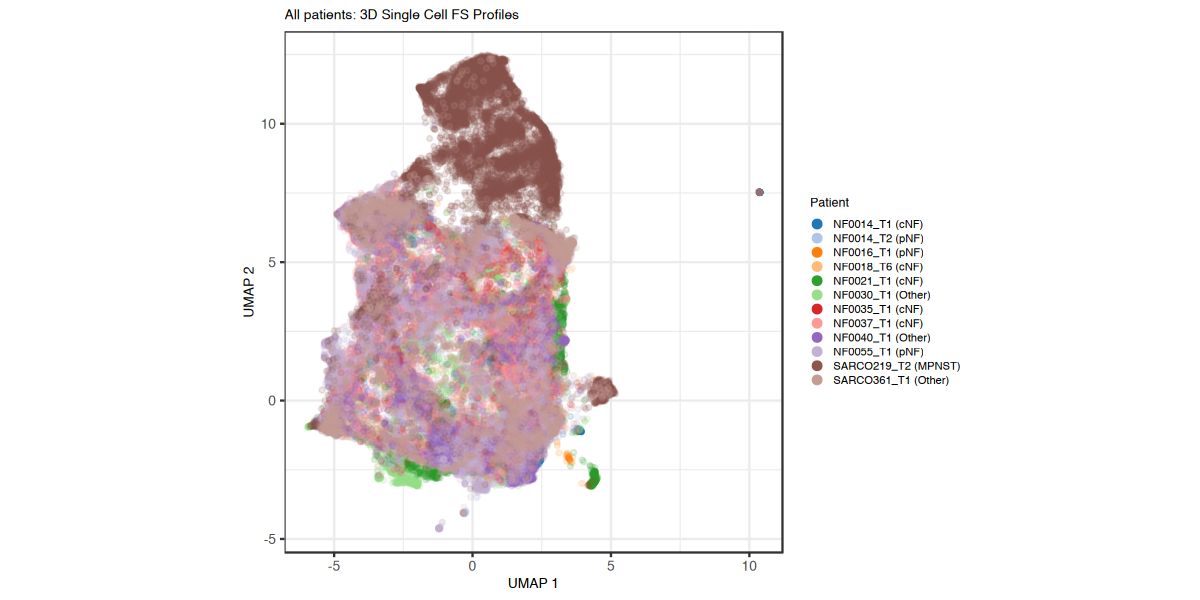

In [12]:
plot_umap(
  data = sc_3D_umap_results,
  color_by = "Metadata_Biology_PatientTumorLabel",
  palette = patient_color_palette_labeled,
  title = "All patients: 3D Single Cell FS Profiles",
  legend_title = "Patient",
  alpha = 0.15
)

3D facet by patient, highlighted in red against the full distribution

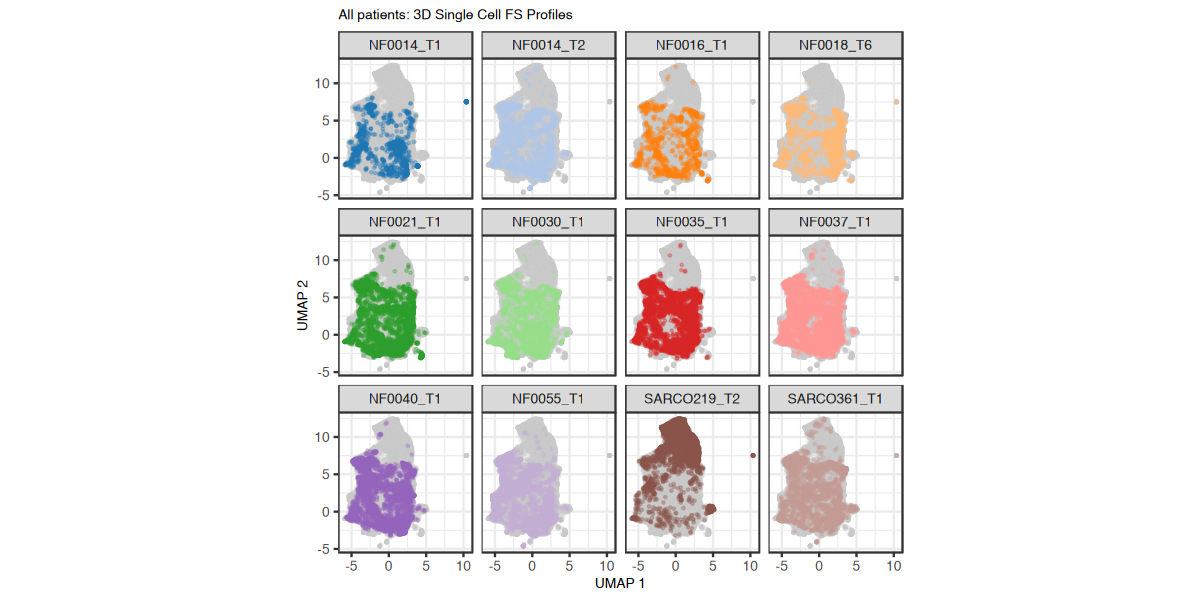

In [13]:
plot_umap(
  data = sc_3D_umap_results,
  color_by = "Metadata_Biology_PatientTumor",
  palette = patient_color_palette,
  title = "All patients: 3D Single Cell FS Profiles",
  facet_by = "Metadata_Biology_PatientTumor",
  facet_nrow = 3,
  alpha = 0.3,
  point_size = 0.3
)

3D colored by treatment

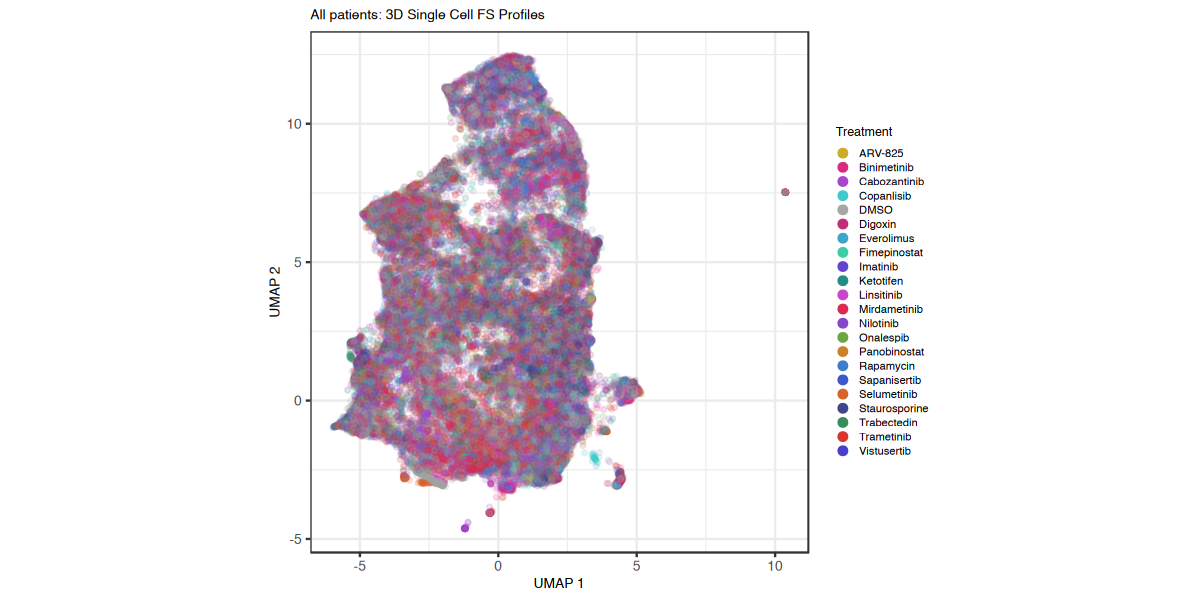

In [14]:
plot_umap(
  data = sc_3D_umap_results,
  color_by = "Metadata_Experiment_Treatment",
  palette = custom_treatment_palette,
  title = "All patients: 3D Single Cell FS Profiles",
  legend_title = "Treatment",
  alpha = 0.15
)

3D facet by treatment, highlighted in red against the full distribution

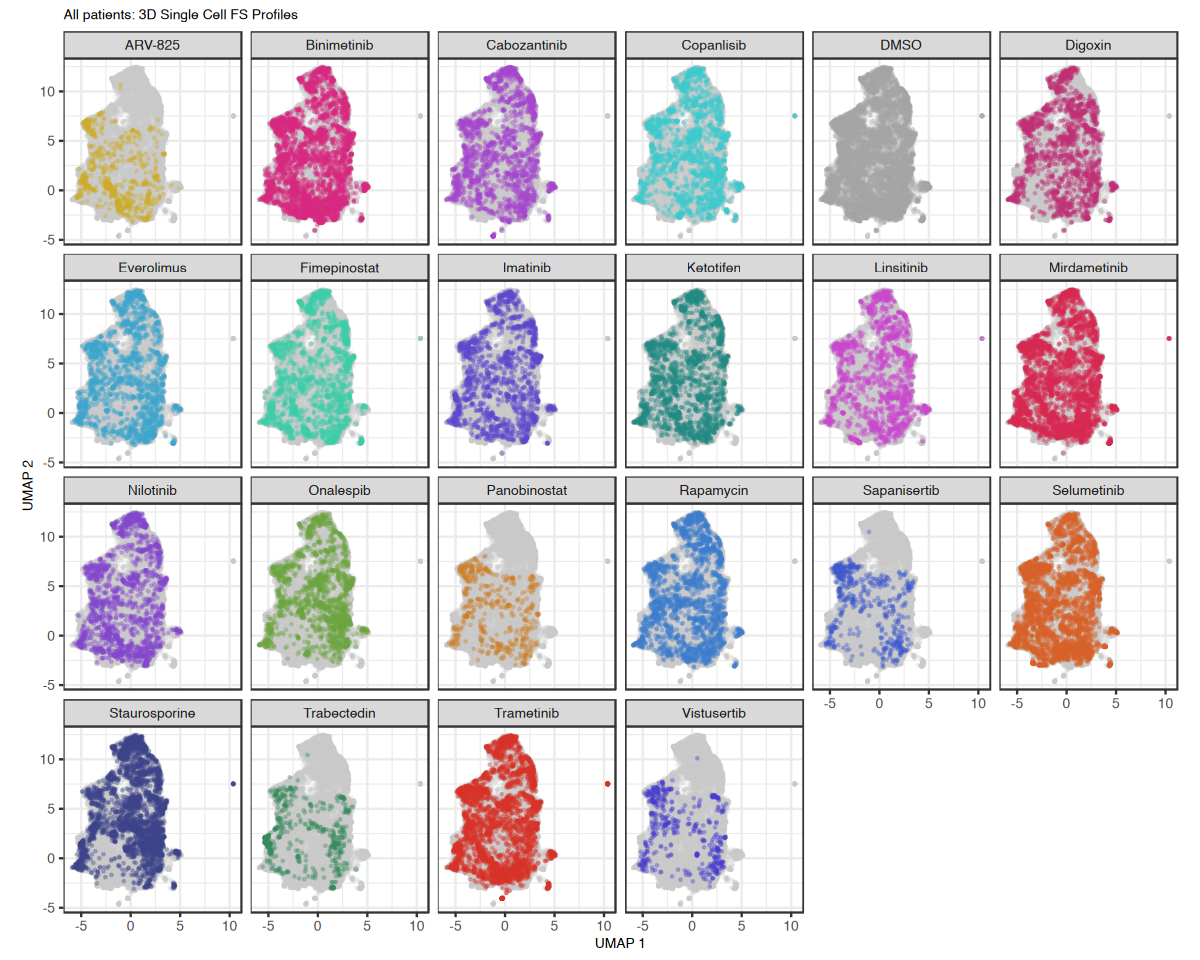

In [15]:
plot_umap(
  data = sc_3D_umap_results,
  color_by = "Metadata_Experiment_Treatment",
  palette = custom_treatment_palette,
  title = "All patients: 3D Single Cell FS Profiles",
  facet_by = "Metadata_Experiment_Treatment",
  facet_nrow = 4,
  alpha = 0.3,
  point_size = 0.3,
  height = 8
)

3D colored by tumor type

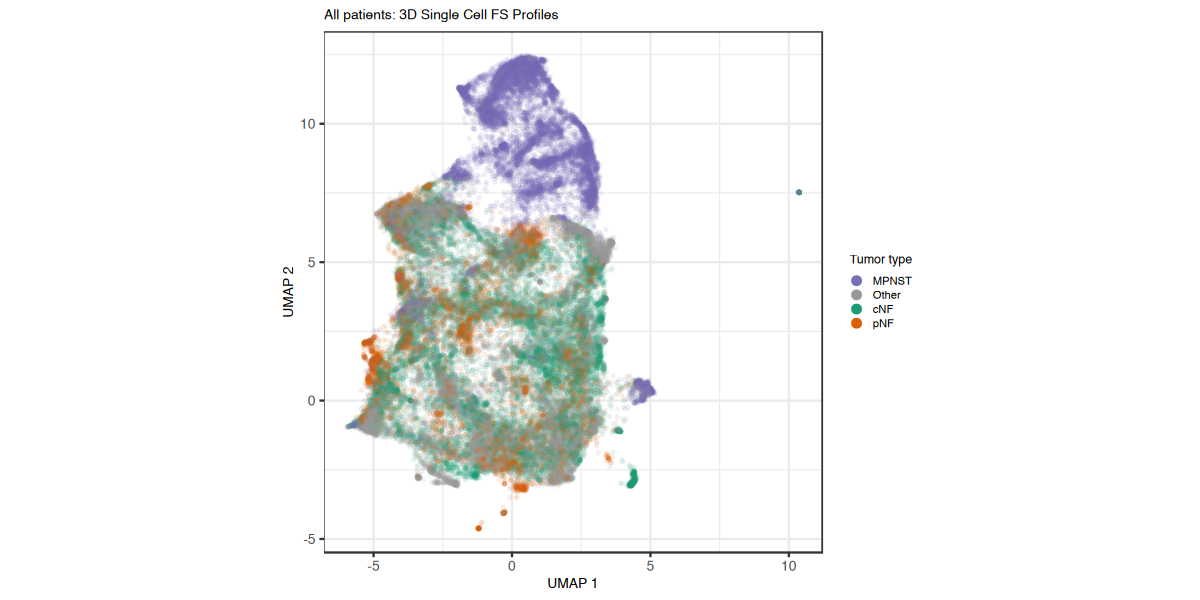

In [16]:
plot_umap(
  data = sc_3D_umap_results,
  color_by = "Metadata_Biology_TumorType",
  palette = tumor_type_palette,
  title = "All patients: 3D Single Cell FS Profiles",
  legend_title = "Tumor type",
  alpha = 0.08,
  point_size = 0.5
)

3D facet by tumor type, highlighted in red against the full distribution

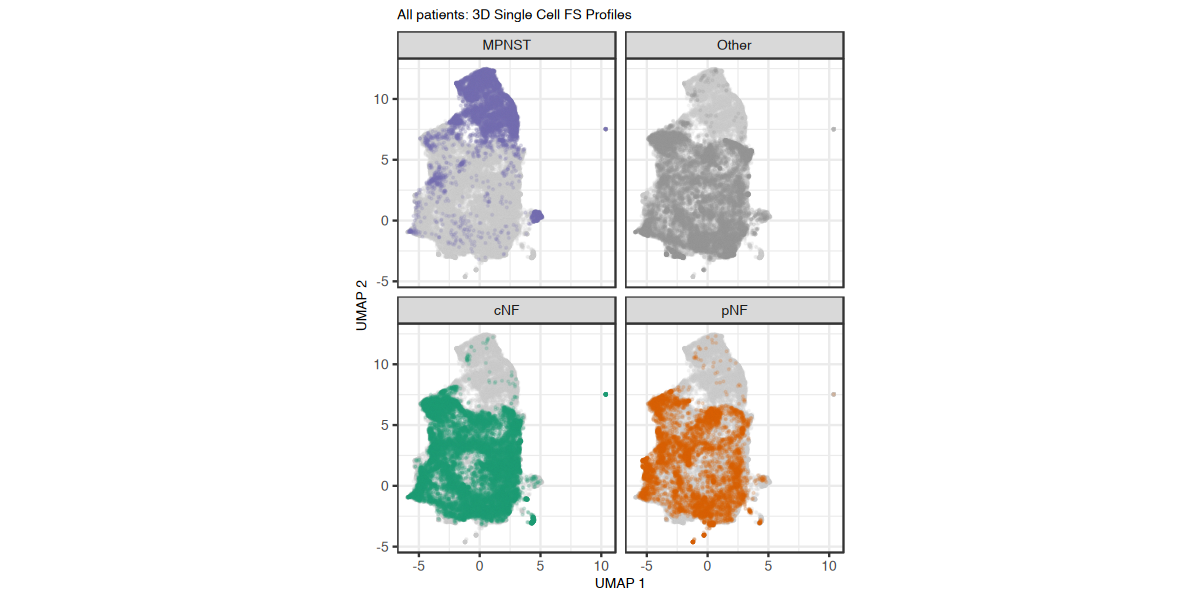

In [17]:
plot_umap(
  data = sc_3D_umap_results,
  color_by = "Metadata_Biology_TumorType",
  palette = tumor_type_palette,
  title = "All patients: 3D Single Cell FS Profiles",
  facet_by = "Metadata_Biology_TumorType",
  facet_nrow = 2,
  alpha = 0.15,
  point_size = 0.15
)

3D control only (DMSO)

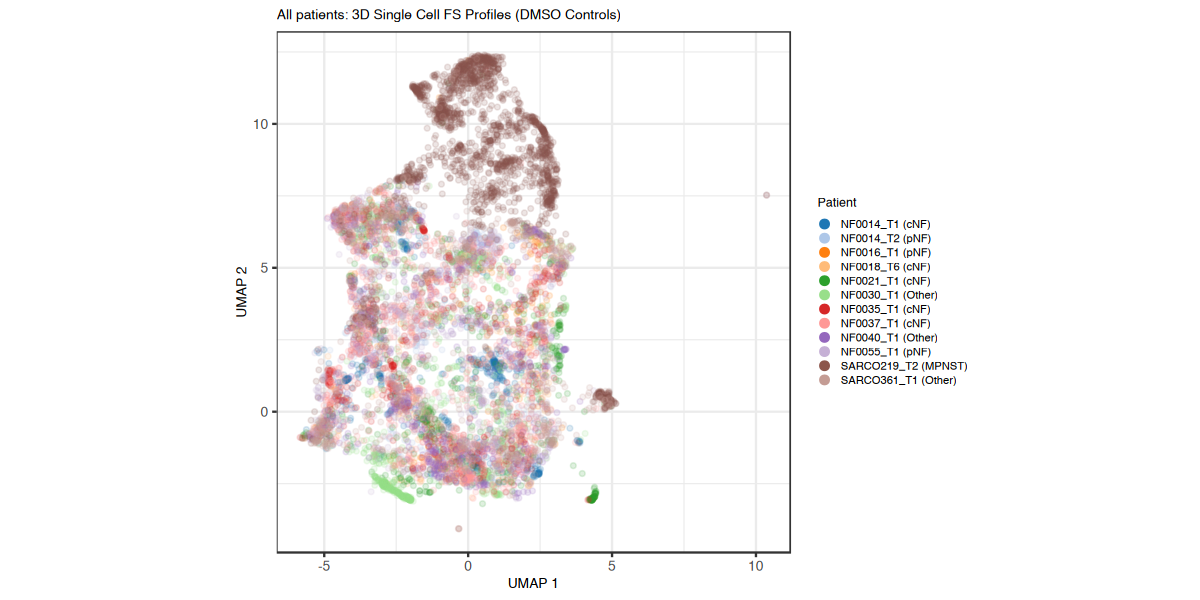

In [18]:
# Filter for DMSO only
sc_umap_results_dmsos <- sc_3D_umap_results %>%
  filter(Metadata_Experiment_Treatment == "DMSO")

plot_umap(
  data = sc_umap_results_dmsos,
  color_by = "Metadata_Biology_PatientTumorLabel",
  palette = patient_color_palette_labeled,
  title = "All patients: 3D Single Cell FS Profiles (DMSO Controls)",
  legend_title = "Patient",
  alpha = 0.15
)

3D control only (DMSO), faceted by patient

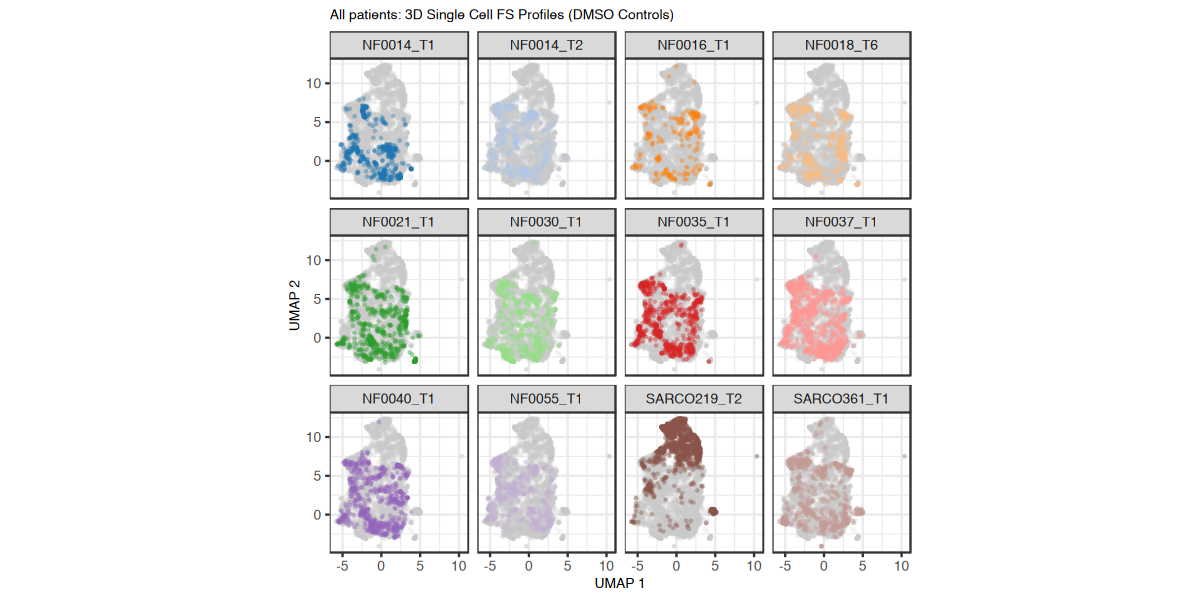

In [19]:
plot_umap(
  data = sc_umap_results_dmsos,
  color_by = "Metadata_Biology_PatientTumor",
  palette = patient_color_palette,
  title = "All patients: 3D Single Cell FS Profiles (DMSO Controls)",
  facet_by = "Metadata_Biology_PatientTumor",
  facet_nrow = 3,
  alpha = 0.3,
  point_size = 0.3
)

Combine the 6 plots above into a single PDF

In [20]:
pdf_plots_3D <- list(
  by_patient = plot_umap(
    data = sc_3D_umap_results,
    color_by = "Metadata_Biology_PatientTumorLabel",
    palette = patient_color_palette_labeled,
    title = "All patients: 3D Single Cell FS Profiles",
    legend_title = "Patient",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  facet_by_patient = plot_umap(
    data = sc_3D_umap_results,
    color_by = "Metadata_Biology_PatientTumor",
    palette = patient_color_palette,
    title = "All patients: 3D Single Cell FS Profiles",
    facet_by = "Metadata_Biology_PatientTumor",
    facet_nrow = 3,
    alpha = 0.3,
    point_size = 0.3,
    rasterize_dpi = 150
  ),
  by_treatment = plot_umap(
    data = sc_3D_umap_results,
    color_by = "Metadata_Experiment_Treatment",
    palette = custom_treatment_palette,
    title = "All patients: 3D Single Cell FS Profiles",
    legend_title = "Treatment",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  facet_by_treatment = plot_umap(
    data = sc_3D_umap_results,
    color_by = "Metadata_Experiment_Treatment",
    palette = custom_treatment_palette,
    title = "All patients: 3D Single Cell FS Profiles",
    facet_by = "Metadata_Experiment_Treatment",
    facet_nrow = 4,
    alpha = 0.3,
    point_size = 0.3,
    height = 8,
    rasterize_dpi = 150
  ),
  by_tumor_type = plot_umap(
    data = sc_3D_umap_results,
    color_by = "Metadata_Biology_TumorType",
    palette = tumor_type_palette,
    title = "All patients: 3D Single Cell FS Profiles",
    legend_title = "Tumor type",
    alpha = 0.08,
    point_size = 0.5,
    rasterize_dpi = 150
  ),
  facet_by_tumor_type = plot_umap(
    data = sc_3D_umap_results,
    color_by = "Metadata_Biology_TumorType",
    palette = tumor_type_palette,
    title = "All patients: 3D Single Cell FS Profiles",
    facet_by = "Metadata_Biology_TumorType",
    facet_nrow = 2,
    alpha = 0.15,
    point_size = 0.15,
    rasterize_dpi = 150
  ),
  dmso_only = plot_umap(
    data = sc_umap_results_dmsos,
    color_by = "Metadata_Biology_PatientTumorLabel",
    palette = patient_color_palette_labeled,
    title = "All patients: 3D Single Cell FS Profiles (DMSO Controls)",
    legend_title = "Patient",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  dmso_facet_by_patient = plot_umap(
    data = sc_umap_results_dmsos,
    color_by = "Metadata_Biology_PatientTumor",
    palette = patient_color_palette,
    title = "All patients: 3D Single Cell FS Profiles (DMSO Controls)",
    facet_by = "Metadata_Biology_PatientTumor",
    facet_nrow = 3,
    alpha = 0.3,
    point_size = 0.3,
    rasterize_dpi = 150
  )
)
save_plots_pdf(pdf_plots_3D, file.path(figures_path, "3D_scfs_all_patients.pdf"))

## 2D Max Projection Analysis

Same plot set as the 3D section above, for the 2D max-projection UMAP. Also bundled into a combined PDF (no individual PNGs).

2D MIP colored by patient

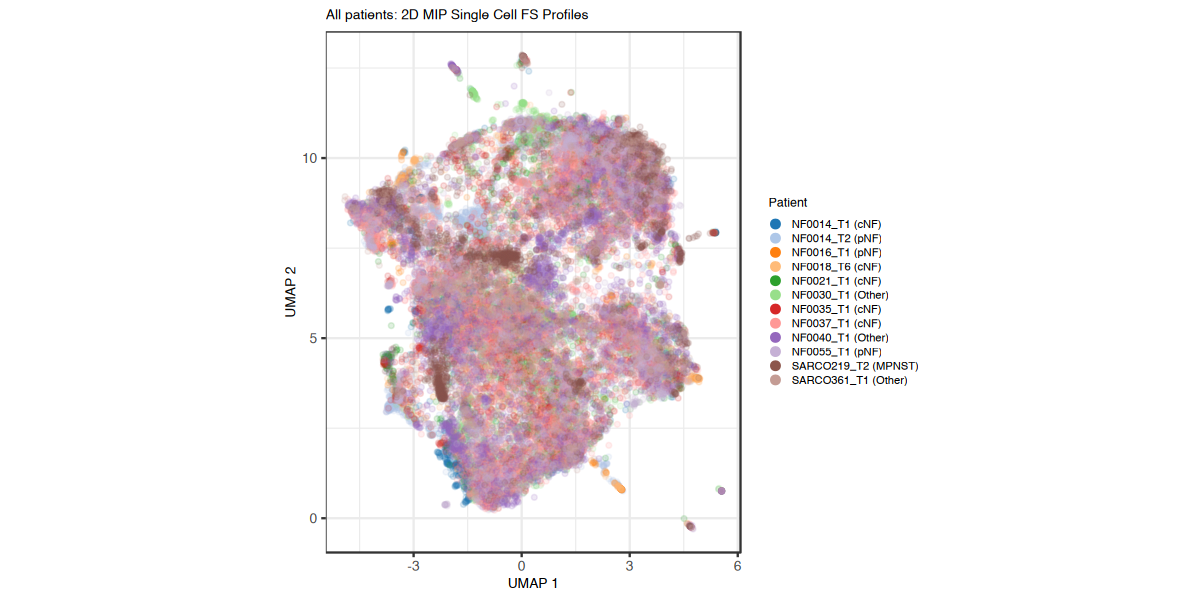

In [21]:
plot_umap(
  data = max_projection_2D_sc_umap_results,
  color_by = "Metadata_Biology_PatientTumorLabel",
  palette = patient_color_palette_labeled,
  title = "All patients: 2D MIP Single Cell FS Profiles",
  legend_title = "Patient",
  alpha = 0.15
)

2D MIP facet by patient, highlighted in red against the full distribution

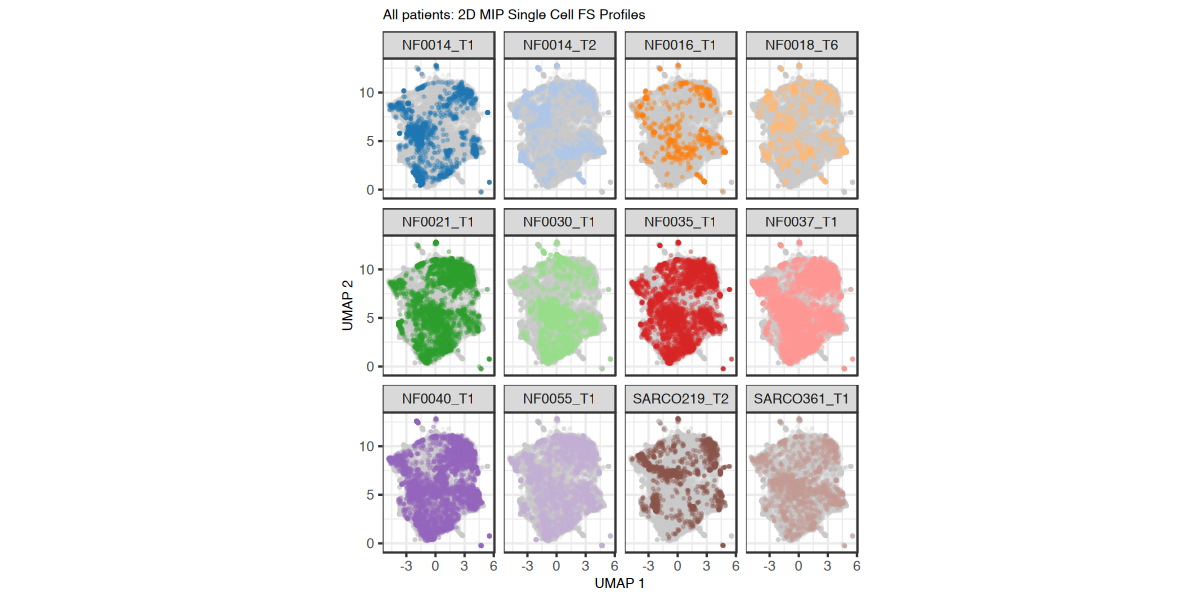

In [22]:
plot_umap(
  data = max_projection_2D_sc_umap_results,
  color_by = "Metadata_Biology_PatientTumor",
  palette = patient_color_palette,
  title = "All patients: 2D MIP Single Cell FS Profiles",
  facet_by = "Metadata_Biology_PatientTumor",
  facet_nrow = 3,
  alpha = 0.3,
  point_size = 0.3
)

2D MIP colored by treatment

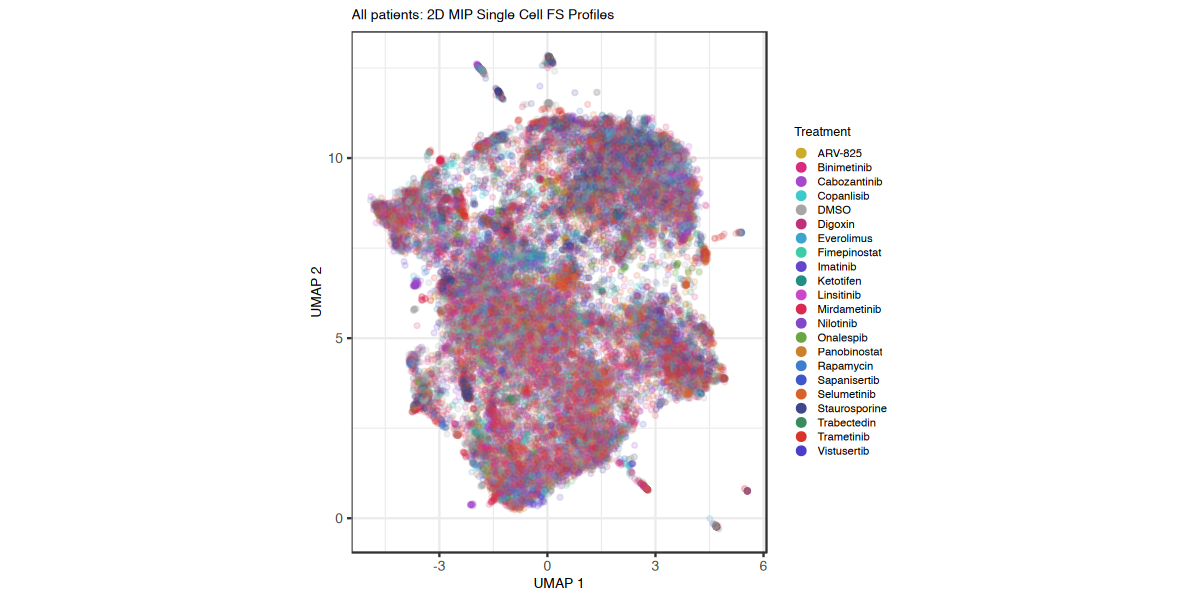

In [23]:
plot_umap(
  data = max_projection_2D_sc_umap_results,
  color_by = "Metadata_Experiment_Treatment",
  palette = custom_treatment_palette,
  title = "All patients: 2D MIP Single Cell FS Profiles",
  legend_title = "Treatment",
  alpha = 0.15
)

2D MIP facet by treatment, highlighted in red against the full distribution

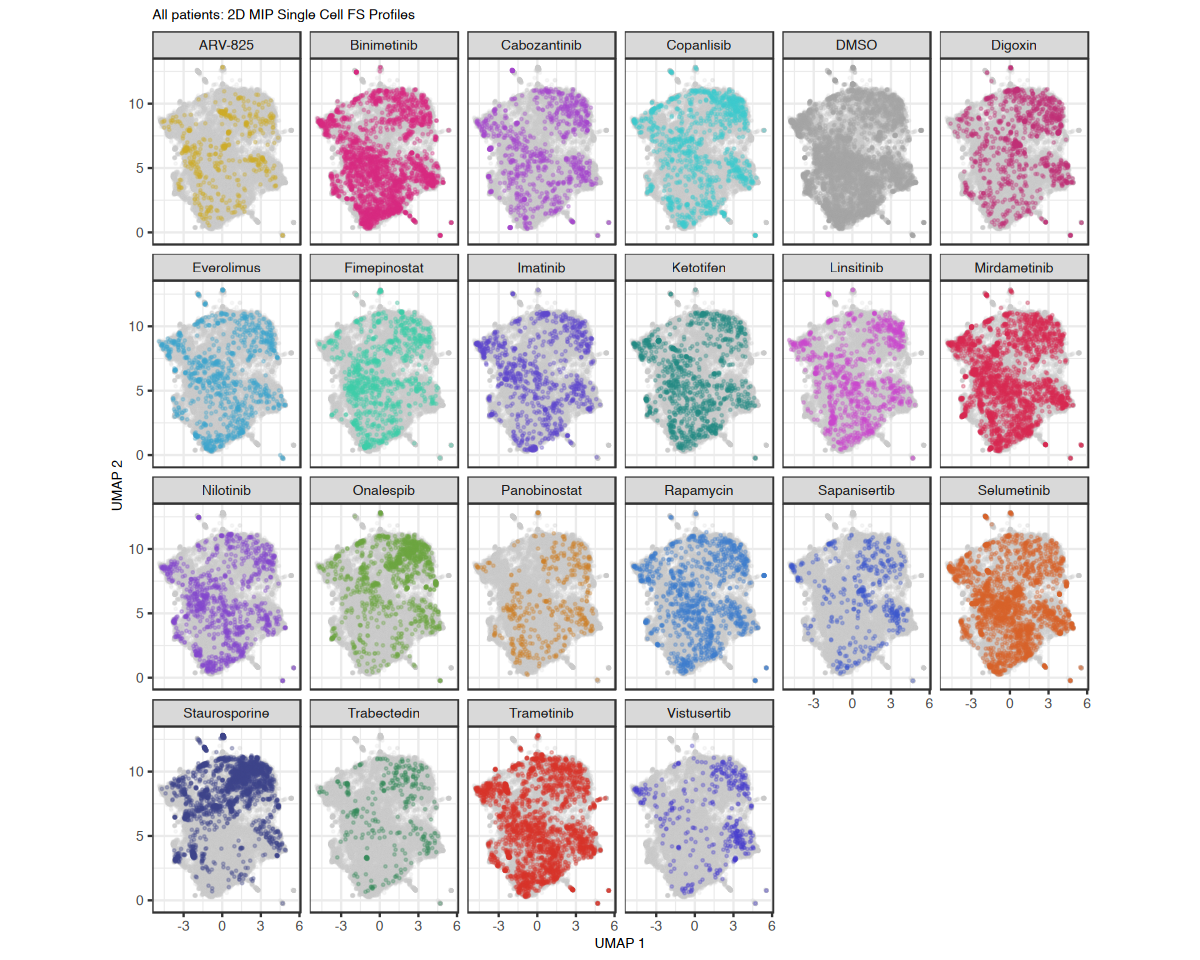

In [24]:
plot_umap(
  data = max_projection_2D_sc_umap_results,
  color_by = "Metadata_Experiment_Treatment",
  palette = custom_treatment_palette,
  title = "All patients: 2D MIP Single Cell FS Profiles",
  facet_by = "Metadata_Experiment_Treatment",
  facet_nrow = 4,
  alpha = 0.3,
  point_size = 0.3,
  height = 8
)

2D MIP colored by tumor type

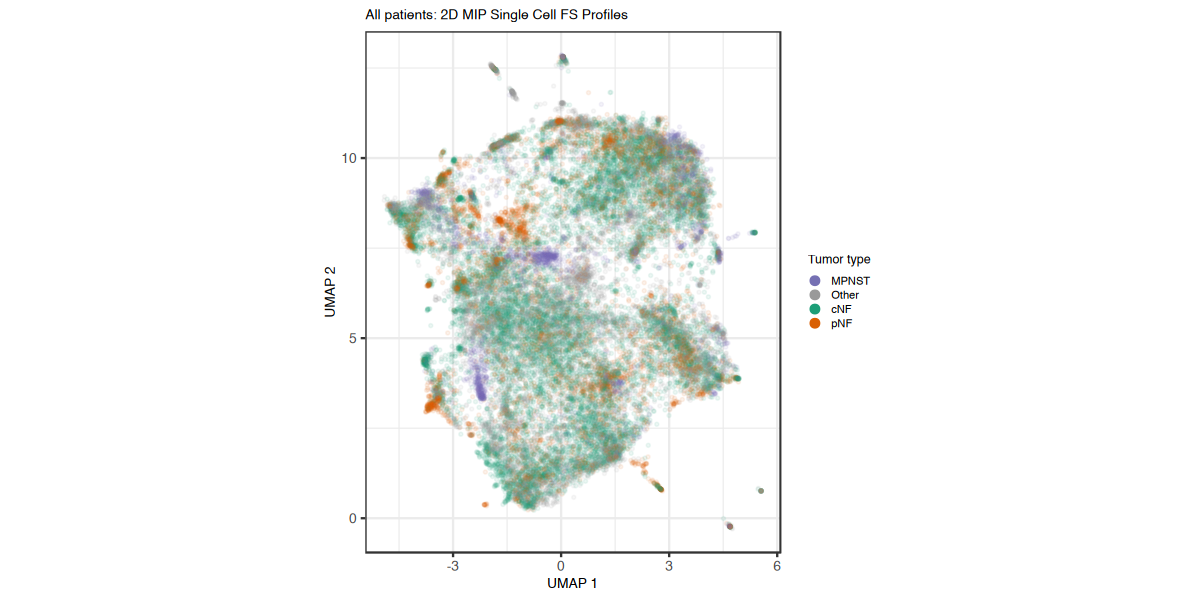

In [25]:
plot_umap(
  data = max_projection_2D_sc_umap_results,
  color_by = "Metadata_Biology_TumorType",
  palette = tumor_type_palette,
  title = "All patients: 2D MIP Single Cell FS Profiles",
  legend_title = "Tumor type",
  alpha = 0.08,
  point_size = 0.5
)

2D MIP facet by tumor type, highlighted in red against the full distribution

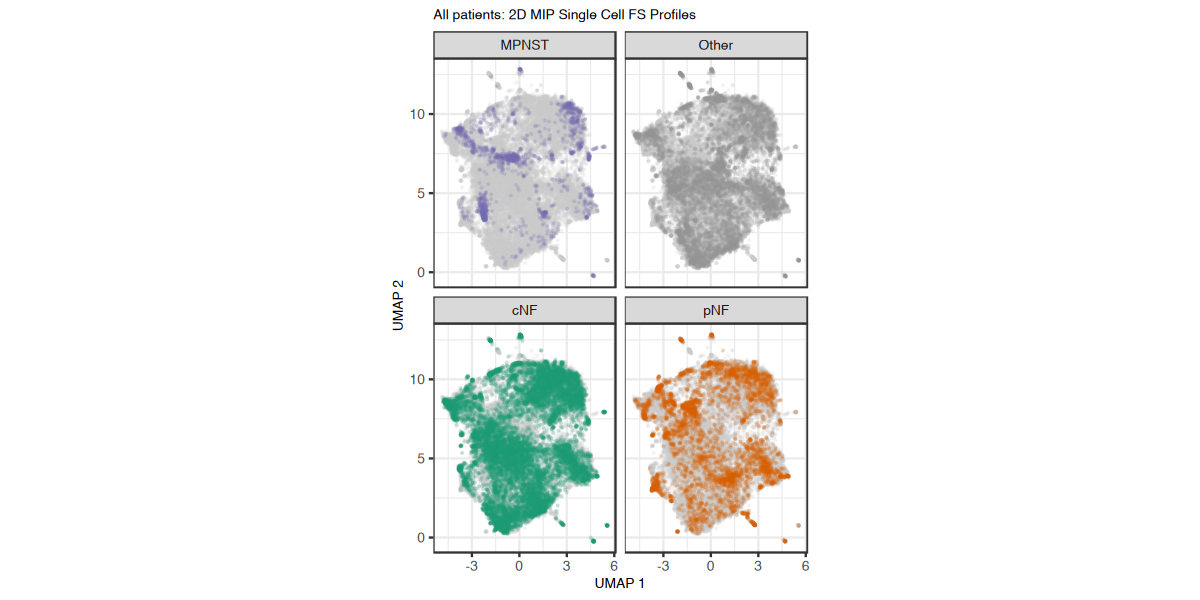

In [26]:
plot_umap(
  data = max_projection_2D_sc_umap_results,
  color_by = "Metadata_Biology_TumorType",
  palette = tumor_type_palette,
  title = "All patients: 2D MIP Single Cell FS Profiles",
  facet_by = "Metadata_Biology_TumorType",
  facet_nrow = 2,
  alpha = 0.15,
  point_size = 0.15
)

2D MIP control only (DMSO)

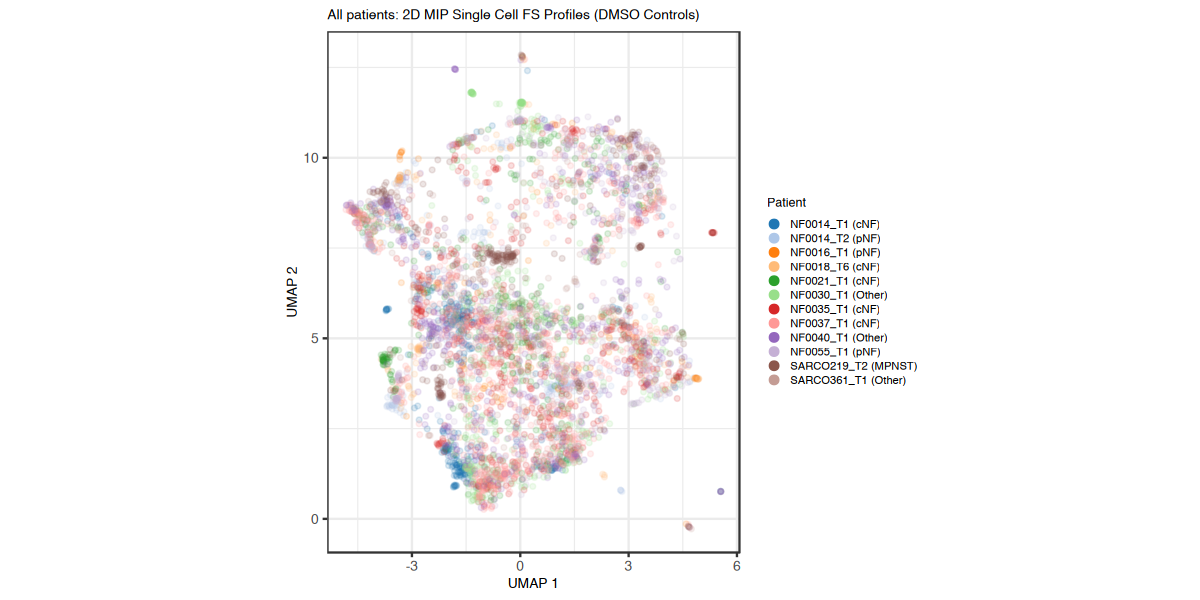

In [27]:
# Filter for DMSO only
sc_umap_results_dmsos <- max_projection_2D_sc_umap_results %>%
  filter(Metadata_Experiment_Treatment == "DMSO")

plot_umap(
  data = sc_umap_results_dmsos,
  color_by = "Metadata_Biology_PatientTumorLabel",
  palette = patient_color_palette_labeled,
  title = "All patients: 2D MIP Single Cell FS Profiles (DMSO Controls)",
  legend_title = "Patient",
  alpha = 0.15
)

2D MIP control only (DMSO), faceted by patient

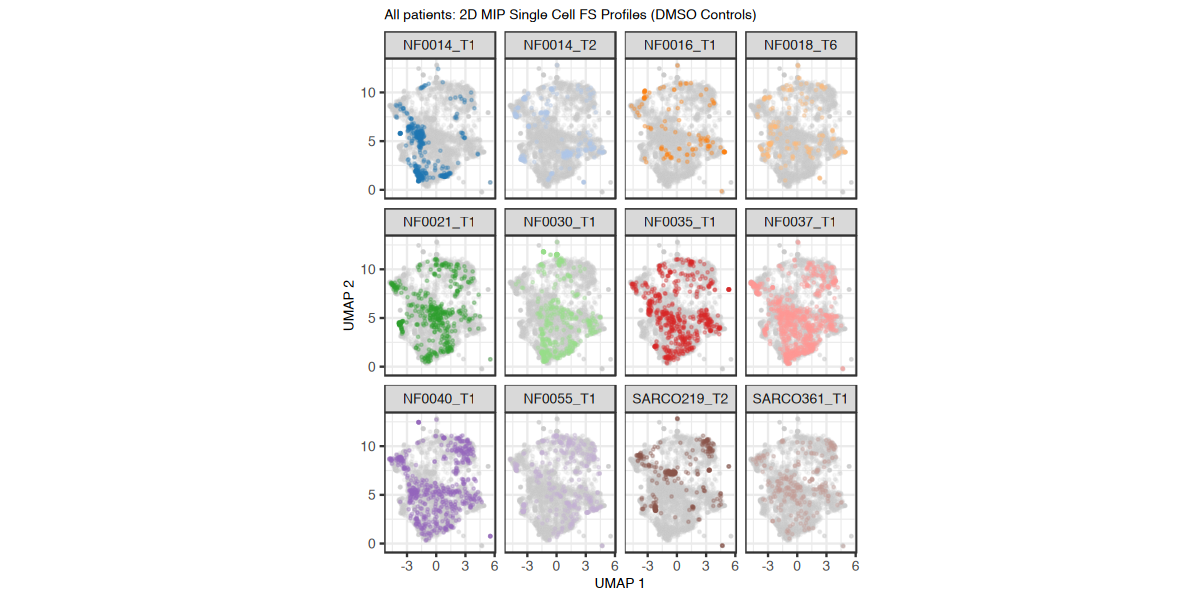

In [28]:
plot_umap(
  data = sc_umap_results_dmsos,
  color_by = "Metadata_Biology_PatientTumor",
  palette = patient_color_palette,
  title = "All patients: 2D MIP Single Cell FS Profiles (DMSO Controls)",
  facet_by = "Metadata_Biology_PatientTumor",
  facet_nrow = 3,
  alpha = 0.3,
  point_size = 0.3
)

Combine the 6 plots above into a single PDF

In [29]:
pdf_plots_2D_maxproj <- list(
  by_patient = plot_umap(
    data = max_projection_2D_sc_umap_results,
    color_by = "Metadata_Biology_PatientTumorLabel",
    palette = patient_color_palette_labeled,
    title = "All patients: 2D MIP Single Cell FS Profiles",
    legend_title = "Patient",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  facet_by_patient = plot_umap(
    data = max_projection_2D_sc_umap_results,
    color_by = "Metadata_Biology_PatientTumor",
    palette = patient_color_palette,
    title = "All patients: 2D MIP Single Cell FS Profiles",
    facet_by = "Metadata_Biology_PatientTumor",
    facet_nrow = 3,
    alpha = 0.3,
    point_size = 0.3,
    rasterize_dpi = 150
  ),
  by_treatment = plot_umap(
    data = max_projection_2D_sc_umap_results,
    color_by = "Metadata_Experiment_Treatment",
    palette = custom_treatment_palette,
    title = "All patients: 2D MIP Single Cell FS Profiles",
    legend_title = "Treatment",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  facet_by_treatment = plot_umap(
    data = max_projection_2D_sc_umap_results,
    color_by = "Metadata_Experiment_Treatment",
    palette = custom_treatment_palette,
    title = "All patients: 2D MIP Single Cell FS Profiles",
    facet_by = "Metadata_Experiment_Treatment",
    facet_nrow = 4,
    alpha = 0.3,
    point_size = 0.3,
    height = 8,
    rasterize_dpi = 150
  ),
  by_tumor_type = plot_umap(
    data = max_projection_2D_sc_umap_results,
    color_by = "Metadata_Biology_TumorType",
    palette = tumor_type_palette,
    title = "All patients: 2D MIP Single Cell FS Profiles",
    legend_title = "Tumor type",
    alpha = 0.08,
    point_size = 0.5,
    rasterize_dpi = 150
  ),
  facet_by_tumor_type = plot_umap(
    data = max_projection_2D_sc_umap_results,
    color_by = "Metadata_Biology_TumorType",
    palette = tumor_type_palette,
    title = "All patients: 2D MIP Single Cell FS Profiles",
    facet_by = "Metadata_Biology_TumorType",
    facet_nrow = 2,
    alpha = 0.15,
    point_size = 0.15,
    rasterize_dpi = 150
  ),
  dmso_only = plot_umap(
    data = sc_umap_results_dmsos,
    color_by = "Metadata_Biology_PatientTumorLabel",
    palette = patient_color_palette_labeled,
    title = "All patients: 2D MIP Single Cell FS Profiles (DMSO Controls)",
    legend_title = "Patient",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  dmso_facet_by_patient = plot_umap(
    data = sc_umap_results_dmsos,
    color_by = "Metadata_Biology_PatientTumor",
    palette = patient_color_palette,
    title = "All patients: 2D MIP Single Cell FS Profiles (DMSO Controls)",
    facet_by = "Metadata_Biology_PatientTumor",
    facet_nrow = 3,
    alpha = 0.3,
    point_size = 0.3,
    rasterize_dpi = 150
  )
)
save_plots_pdf(pdf_plots_2D_maxproj, file.path(figures_path, "2D_maxproj_scfs_all_patients.pdf"))

## 2D Middle Slice Analysis

Same plot set as above, for the 2D middle-slice UMAP. Also bundled into a combined PDF (no individual PNGs).

2D MS by patient

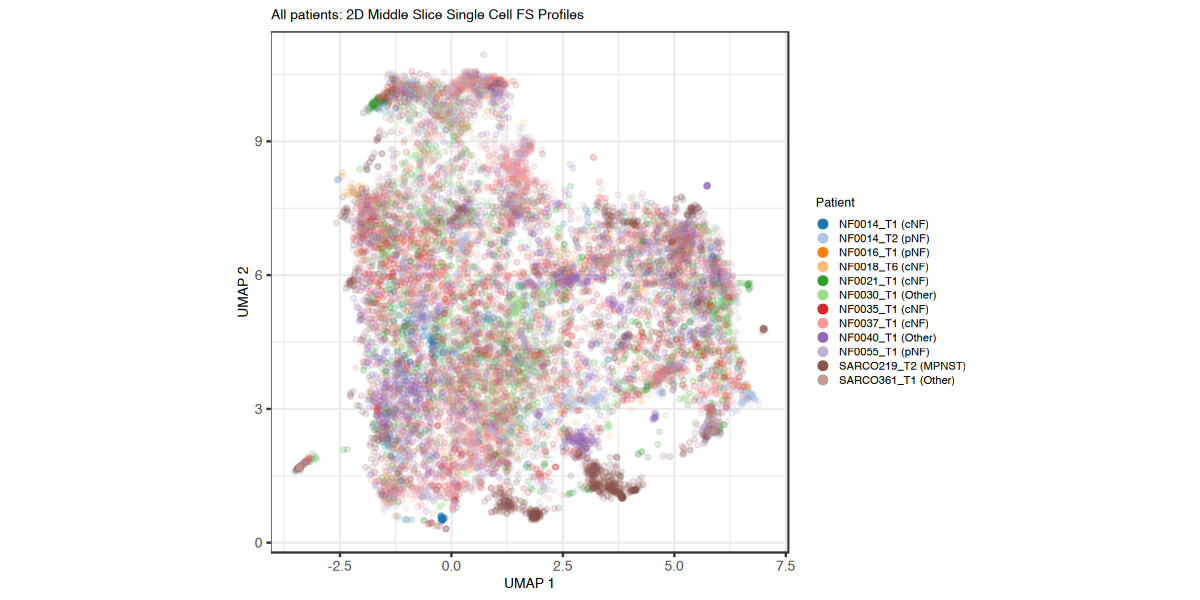

In [30]:
plot_umap(
  data = middle_slice_2D_sc_umap_results,
  color_by = "Metadata_Biology_PatientTumorLabel",
  palette = patient_color_palette_labeled,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles",
  legend_title = "Patient",
  alpha = 0.15
)

2D MS facet by patient, highlighted in red against the full distribution

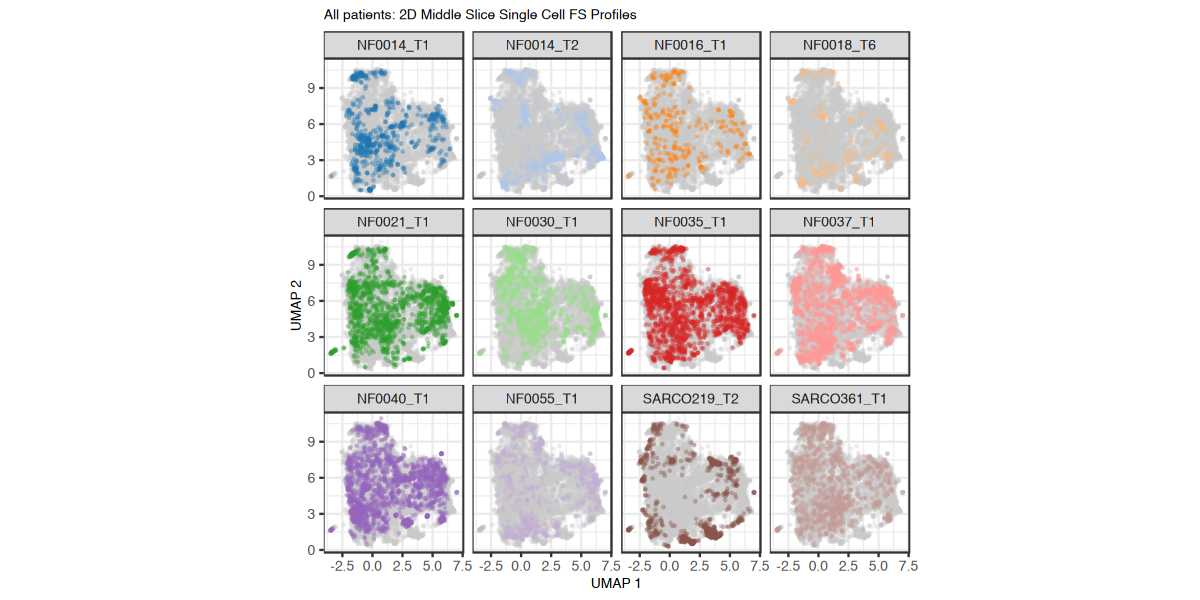

In [31]:
plot_umap(
  data = middle_slice_2D_sc_umap_results,
  color_by = "Metadata_Biology_PatientTumor",
  palette = patient_color_palette,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles",
  facet_by = "Metadata_Biology_PatientTumor",
  facet_nrow = 3,
  alpha = 0.3,
  point_size = 0.3
)

2D MS by treatment

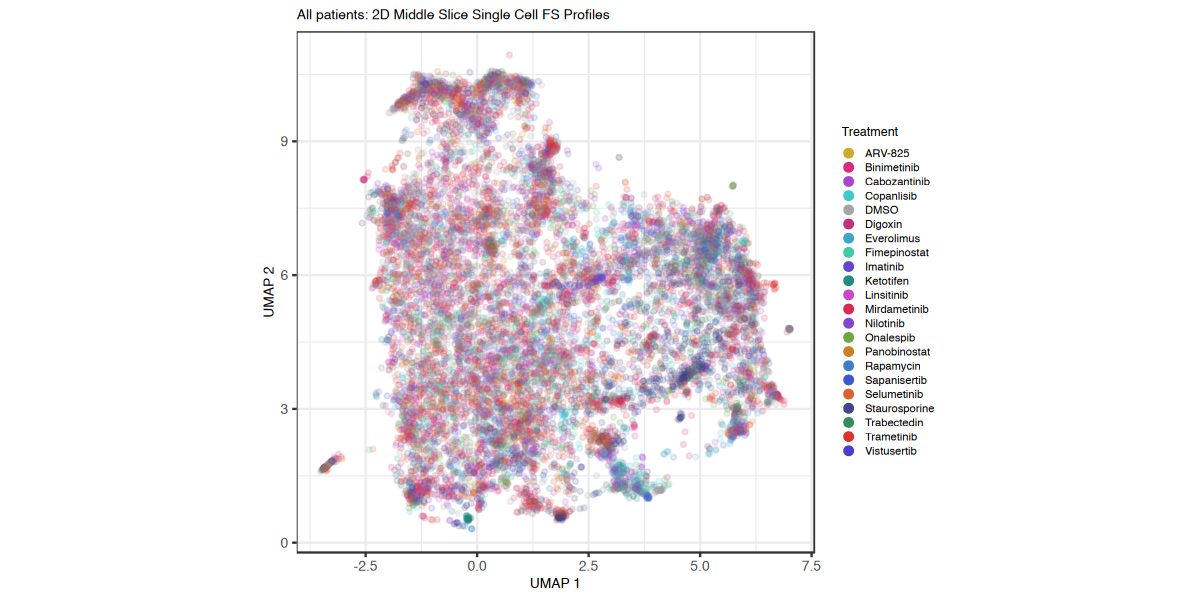

In [32]:
plot_umap(
  data = middle_slice_2D_sc_umap_results,
  color_by = "Metadata_Experiment_Treatment",
  palette = custom_treatment_palette,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles",
  legend_title = "Treatment",
  alpha = 0.15
)

2D MS facet by treatment, highlighted in red against the full distribution

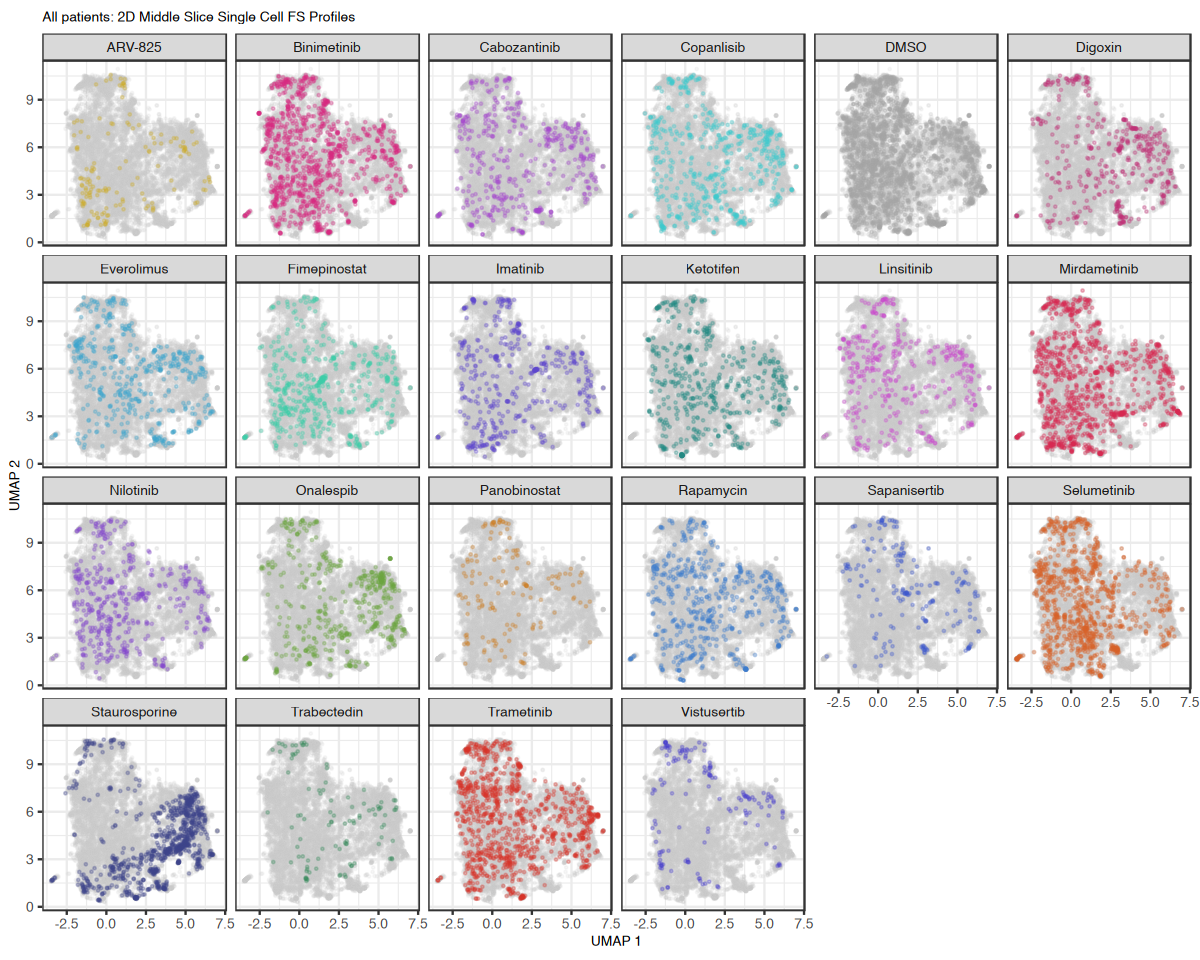

In [33]:
plot_umap(
  data = middle_slice_2D_sc_umap_results,
  color_by = "Metadata_Experiment_Treatment",
  palette = custom_treatment_palette,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles",
  facet_by = "Metadata_Experiment_Treatment",
  facet_nrow = 4,
  alpha = 0.3,
  point_size = 0.3,
  height = 8
)

2D MS colored by tumor type

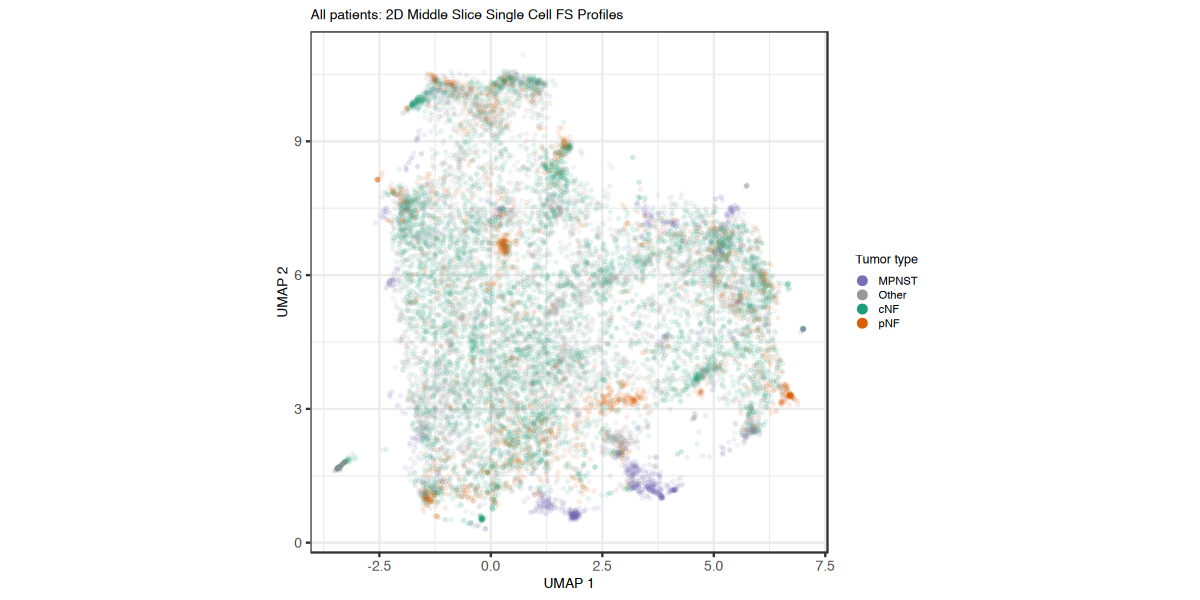

In [34]:
plot_umap(
  data = middle_slice_2D_sc_umap_results,
  color_by = "Metadata_Biology_TumorType",
  palette = tumor_type_palette,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles",
  legend_title = "Tumor type",
  alpha = 0.08,
  point_size = 0.5
)

2D MS facet by tumor type, highlighted in red against the full distribution

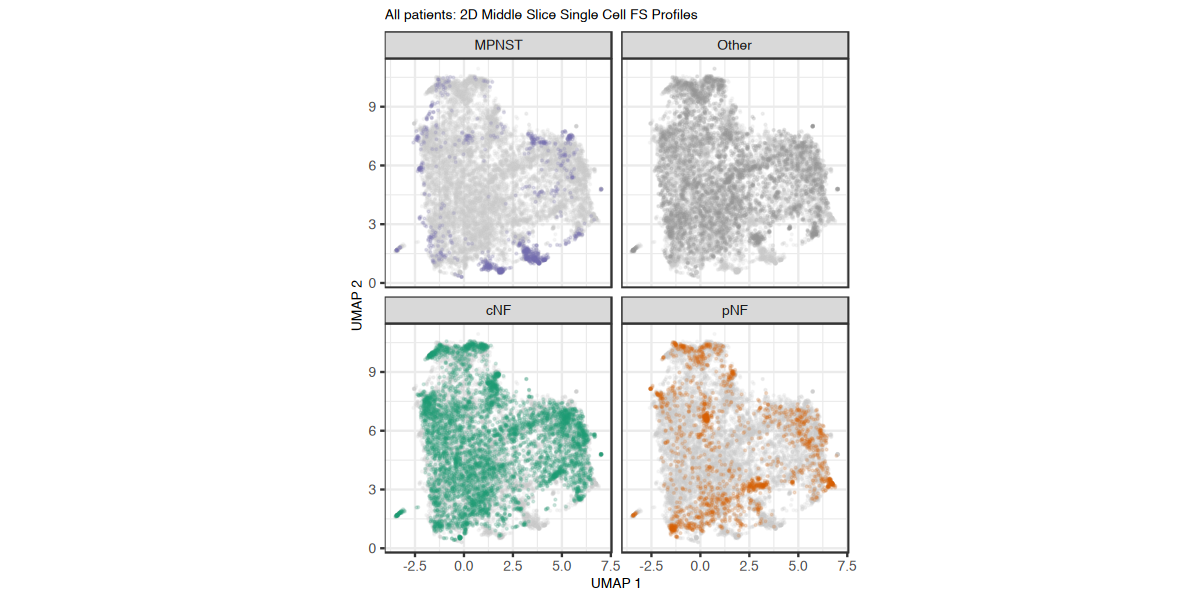

In [35]:
plot_umap(
  data = middle_slice_2D_sc_umap_results,
  color_by = "Metadata_Biology_TumorType",
  palette = tumor_type_palette,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles",
  facet_by = "Metadata_Biology_TumorType",
  facet_nrow = 2,
  alpha = 0.15,
  point_size = 0.15
)

2D MS controls only (DMSO)

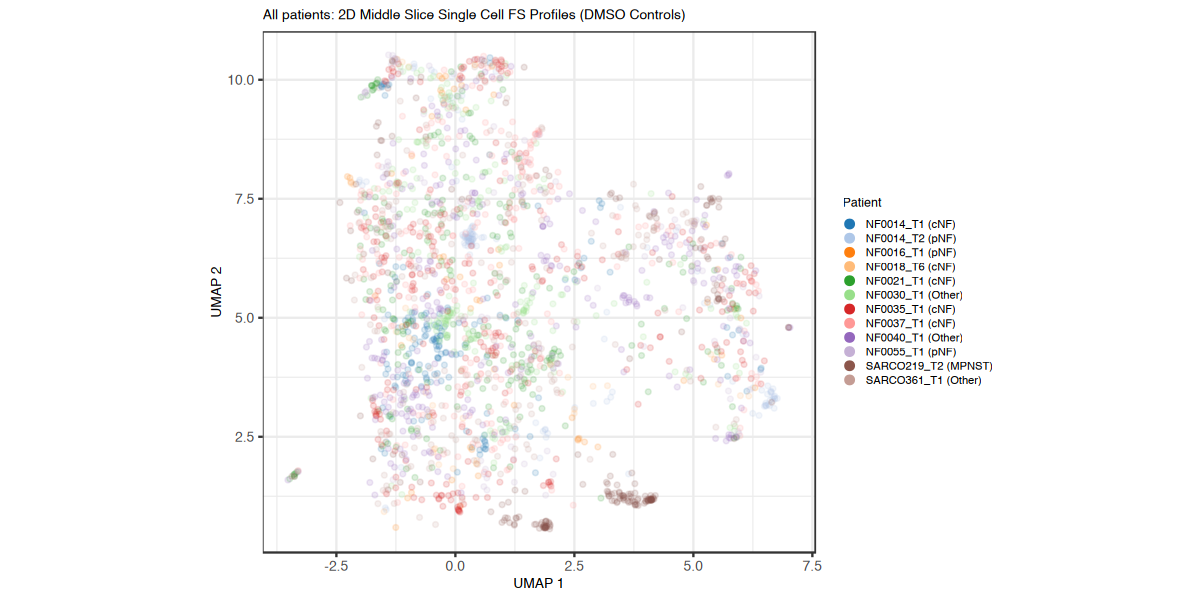

In [36]:
# Filter for DMSO only
sc_umap_results_dmsos <- middle_slice_2D_sc_umap_results %>%
  filter(Metadata_Experiment_Treatment == "DMSO")

plot_umap(
  data = sc_umap_results_dmsos,
  color_by = "Metadata_Biology_PatientTumorLabel",
  palette = patient_color_palette_labeled,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles (DMSO Controls)",
  legend_title = "Patient",
  alpha = 0.15
)

2D MS controls only (DMSO), faceted by patient

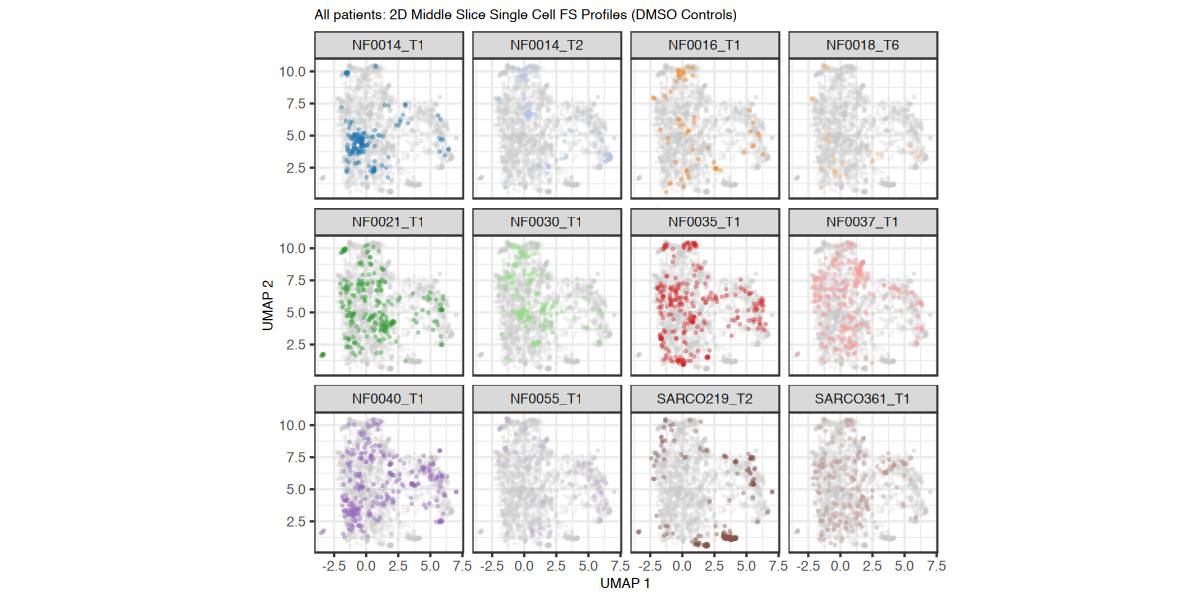

In [37]:
plot_umap(
  data = sc_umap_results_dmsos,
  color_by = "Metadata_Biology_PatientTumor",
  palette = patient_color_palette,
  title = "All patients: 2D Middle Slice Single Cell FS Profiles (DMSO Controls)",
  facet_by = "Metadata_Biology_PatientTumor",
  facet_nrow = 3,
  alpha = 0.3,
  point_size = 0.3
)

Combine the 6 plots above into a single PDF

In [38]:
pdf_plots_2D_midslice <- list(
  by_patient = plot_umap(
    data = middle_slice_2D_sc_umap_results,
    color_by = "Metadata_Biology_PatientTumorLabel",
    palette = patient_color_palette_labeled,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles",
    legend_title = "Patient",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  facet_by_patient = plot_umap(
    data = middle_slice_2D_sc_umap_results,
    color_by = "Metadata_Biology_PatientTumor",
    palette = patient_color_palette,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles",
    facet_by = "Metadata_Biology_PatientTumor",
    facet_nrow = 3,
    alpha = 0.3,
    point_size = 0.3,
    rasterize_dpi = 150
  ),
  by_treatment = plot_umap(
    data = middle_slice_2D_sc_umap_results,
    color_by = "Metadata_Experiment_Treatment",
    palette = custom_treatment_palette,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles",
    legend_title = "Treatment",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  facet_by_treatment = plot_umap(
    data = middle_slice_2D_sc_umap_results,
    color_by = "Metadata_Experiment_Treatment",
    palette = custom_treatment_palette,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles",
    facet_by = "Metadata_Experiment_Treatment",
    facet_nrow = 4,
    alpha = 0.3,
    point_size = 0.3,
    height = 8,
    rasterize_dpi = 150
  ),
  by_tumor_type = plot_umap(
    data = middle_slice_2D_sc_umap_results,
    color_by = "Metadata_Biology_TumorType",
    palette = tumor_type_palette,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles",
    legend_title = "Tumor type",
    alpha = 0.08,
    point_size = 0.5,
    rasterize_dpi = 150
  ),
  facet_by_tumor_type = plot_umap(
    data = middle_slice_2D_sc_umap_results,
    color_by = "Metadata_Biology_TumorType",
    palette = tumor_type_palette,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles",
    facet_by = "Metadata_Biology_TumorType",
    facet_nrow = 2,
    alpha = 0.15,
    point_size = 0.15,
    rasterize_dpi = 150
  ),
  dmso_only = plot_umap(
    data = sc_umap_results_dmsos,
    color_by = "Metadata_Biology_PatientTumorLabel",
    palette = patient_color_palette_labeled,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles (DMSO Controls)",
    legend_title = "Patient",
    alpha = 0.15,
    rasterize_dpi = 150
  ),
  dmso_facet_by_patient = plot_umap(
    data = sc_umap_results_dmsos,
    color_by = "Metadata_Biology_PatientTumor",
    palette = patient_color_palette,
    title = "All patients: 2D Middle Slice Single Cell FS Profiles (DMSO Controls)",
    facet_by = "Metadata_Biology_PatientTumor",
    facet_nrow = 3,
    alpha = 0.3,
    point_size = 0.3,
    rasterize_dpi = 150
  )
)
save_plots_pdf(pdf_plots_2D_midslice, file.path(figures_path, "2D_midslice_scfs_all_patients.pdf"))

## Single patient UMAPs

Per-patient UMAPs (2D max-projection, 2D middle-slice, 3D), colored by treatment. Saved as one combined, multi-page PDF per projection (one page per patient) instead of individual files.

In [39]:
individual_patients <- readLines(file.path(root_dir, "data/patient_IDs.txt"))
individual_patients <- individual_patients[individual_patients != ""]

# NF0037_T1 has no 2D per-patient data (the 2D pipeline never produced output
# for this plate); skip only its 2D plots, not 3D (which is fully populated).
individual_patients_2D <- individual_patients[individual_patients != "NF0037_T1"]

In [40]:
# Consolidated per-patient files: one file per projection/variant combo,
# with all patients' independently-fit UMAP results concatenated together
# and patient identity kept as a metadata column
# (Metadata_Biology_PatientTumor, stamped explicitly at generation time).
# Harmonize the 2D treatment column name to the 3D metadata convention, as
# done for the pooled results above.
patient_specific_2D_maxproj_scfs <- arrow::read_parquet(
  file.path(umap_results_dir, "patient_specific", "patient_specific_2D_maxproj_scfs_umap.parquet")
) %>%
  rename(Metadata_Experiment_Treatment = Metadata_treatment)

patient_specific_2D_midslice_scfs <- arrow::read_parquet(
  file.path(umap_results_dir, "patient_specific", "patient_specific_2D_midslice_scfs_umap.parquet")
) %>%
  rename(Metadata_Experiment_Treatment = Metadata_treatment)

patient_specific_3D_scfs <- arrow::read_parquet(
  file.path(umap_results_dir, "patient_specific", "patient_specific_3D_scfs_umap.parquet")
)

plots_2D_maxproj <- list()
plots_2D_midslice <- list()
plots_3D <- list()

for (patient in individual_patients) {
  if (patient %in% individual_patients_2D) {
    # UMAP1/UMAP2 are only comparable within a patient (each patient has its
    # own independent UMAP fit), so filter to one patient's rows before
    # plotting rather than plotting the consolidated file directly.
    plots_2D_maxproj[[patient]] <- plot_umap(
      data = patient_specific_2D_maxproj_scfs %>% filter(Metadata_Biology_PatientTumor == patient),
      color_by = "Metadata_Experiment_Treatment",
      palette = custom_treatment_palette,
      title = paste0(patient, " - Single-cells MIP FS Profiles"),
      legend_title = "Treatment",
      alpha = 0.15,
      rasterize_dpi = 150
    )

    plots_2D_midslice[[patient]] <- plot_umap(
      data = patient_specific_2D_midslice_scfs %>% filter(Metadata_Biology_PatientTumor == patient),
      color_by = "Metadata_Experiment_Treatment",
      palette = custom_treatment_palette,
      title = paste0(patient, " - Single-cells Middle Slice FS Profiles"),
      legend_title = "Treatment",
      alpha = 0.15,
      rasterize_dpi = 150
    )
  }

  # 3D per-patient data is fully populated for every patient (including NF0037_T1)
  plots_3D[[patient]] <- plot_umap(
    data = patient_specific_3D_scfs %>% filter(Metadata_Biology_PatientTumor == patient),
    color_by = "Metadata_Experiment_Treatment",
    palette = custom_treatment_palette,
    title = paste0(patient, " - Single-cells 3D FS Profiles"),
    legend_title = "Treatment",
    alpha = 0.15,
    rasterize_dpi = 150
  )
}

# One combined, multi-page PDF per projection (one page per patient) instead
# of individual PNGs.
save_plots_pdf(plots_2D_maxproj, file.path(figures_patient_specific_path, "patient_specific_2D_maxproj_scfs_by_treatment.pdf"))
save_plots_pdf(plots_2D_midslice, file.path(figures_patient_specific_path, "patient_specific_2D_midslice_scfs_by_treatment.pdf"))
save_plots_pdf(plots_3D, file.path(figures_patient_specific_path, "patient_specific_3D_scfs_by_treatment.pdf"))